# 04 — Modeling

Four models are trained on the Adult Income dataset.
Each uses a proper preprocessing pipeline — no data leakage.
Model selection is based on multiple criteria: performance,
calibration, interpretability, and fairness considerations.
The goal is not the highest accuracy — it is the most 
appropriate model for responsible deployment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix,
    average_precision_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb

In [2]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## 1. Load Processed Data

In [3]:
train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

# separate features and target
X_train = train.drop(columns=["income"])
y_train = train["income"]

X_test = test.drop(columns=["income"])
y_test = test["income"]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train positive rate: {y_train.mean():.3f}")
print(f"y_test positive rate:  {y_test.mean():.3f}")

X_train: (32561, 18)
X_test:  (16281, 18)
y_train positive rate: 0.241
y_test positive rate:  0.236


## 2. Define Feature Groups

In [4]:
# tree models and logistic regression need different treatment
# define feature groups for ColumnTransformer

# continuous features -- scale for logistic regression
continuous_features = [
    "age", 
    "hours-per-week",
    "capital_gain_log",
    "capital_loss_log"
]

# binary features -- no transformation needed
binary_features = [
    "has_capital_gain",
    "has_capital_loss",
    "is_married"
]

# categorical features -- one-hot encode for logistic regression
categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "native_region",
    "age_group",
    "hours_category"
]

# verify all features accounted for
all_features = continuous_features + binary_features + categorical_features
missing = set(X_train.columns) - set(all_features)
extra = set(all_features) - set(X_train.columns)

print(f"Features in X_train not assigned: {missing}")
print(f"Features assigned but not in X_train: {extra}")
print(f"Total features: {len(all_features)}")

Features in X_train not assigned: set()
Features assigned but not in X_train: set()
Total features: 18


## 3. Preprocessing Pipelines

In [5]:
# logistic regression pipeline -- needs scaling and one-hot encoding
lr_preprocessor = ColumnTransformer(transformers=[
    ("continuous", StandardScaler(), continuous_features),
    ("binary", "passthrough", binary_features),
    ("categorical", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), categorical_features)
])

# tree model preprocessor -- needs ordinal encoding, no scaling
tree_preprocessor = ColumnTransformer(transformers=[
    ("continuous", "passthrough", continuous_features),
    ("binary", "passthrough", binary_features),
    ("categorical", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ), categorical_features)
])

print("Preprocessors defined.")
print()
print("Logistic Regression: StandardScaler + OneHotEncoder")
print("Tree Models: OrdinalEncoder, no scaling")

Preprocessors defined.

Logistic Regression: StandardScaler + OneHotEncoder
Tree Models: OrdinalEncoder, no scaling


## 4. Logistic Regression — Baseline Model

In [6]:
# first create the pipeline for log reg
lr_pipeline = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

In [7]:
# training
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [8]:
# predictions with probabilities
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

In [9]:
# results
print("Logistic Regression")
print("="*50)
print(classification_report(y_test, lr_pred, 
      target_names=["<=50K", ">50K"]))
print(f"ROC-AUC:  {roc_auc_score(y_test, lr_prob):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, lr_prob):.4f}")
print(f"Brier Score:   {brier_score_loss(y_test, lr_prob):.4f}")

Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.87     12435
        >50K       0.57      0.85      0.68      3846

    accuracy                           0.81     16281
   macro avg       0.76      0.83      0.78     16281
weighted avg       0.86      0.81      0.83     16281

ROC-AUC:  0.9095
Avg Precision: 0.7722
Brier Score:   0.1248


### Logistic Regression Results

- **ROC-AUC: 0.9095** — good, strong discriminative ability for a linear model
- **>50K Precision: 0.57** — bad, when it predicts high income, 
  it's right 57% of the time
- **>50K Recall: 0.85** — not bad, catches 85% of actual high earners, 
  thanks to `class_weight="balanced"`
- **Brier Score: 0.1248** — fine, reasonable probability calibration
- **Accuracy: 0.81** — misleading given class imbalance, 
  not the primary metric here

`class_weight="balanced"` deliberately trades precision for recall — 
in a fairness context, missing a high earner (false negative) 
is a different kind of error than falsely predicting high income 
(false positive). We make this tradeoff explicit rather than 
optimizing blindly for accuracy.

This is our baseline. Every subsequent model is evaluated 
against these numbers.

## 5. Random Forest

In [10]:
# random forest pipeline, hyper-parameters coming from best practice, does not mean optimal
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

### Hyperparameter Rationale — Random Forest

- `n_estimators=200` — sufficient for stable predictions on this 
  dataset size, diminishing returns beyond this
- `max_depth=10` — prevents overfitting, keeps trees interpretable
- `min_samples_leaf=20` — each leaf needs at least 20 samples. 
  Important for fairness: very small leaves can memorize 
  demographic subgroup patterns rather than generalizing
- `class_weight="balanced"` — compensates for 75/25 class imbalance, 
  consistent with logistic regression treatment

In [11]:
# training
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [12]:
# predictions with probabilities
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [13]:
# results
print("Random Forest")
print("="*50)
print(classification_report(y_test, rf_pred,
      target_names=["<=50K", ">50K"]))
print(f"ROC-AUC:  {roc_auc_score(y_test, rf_prob):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, rf_prob):.4f}")
print(f"Brier Score:   {brier_score_loss(y_test, rf_prob):.4f}")

Random Forest
              precision    recall  f1-score   support

       <=50K       0.95      0.77      0.85     12435
        >50K       0.54      0.87      0.67      3846

    accuracy                           0.80     16281
   macro avg       0.75      0.82      0.76     16281
weighted avg       0.85      0.80      0.81     16281

ROC-AUC:  0.9098
Avg Precision: 0.7866
Brier Score:   0.1279


### Random Forest Results

- **ROC-AUC: 0.9098** — virtually identical to logistic regression (0.9095)
- **>50K Precision: 0.54** — slightly worse than LR (0.57)
- **>50K Recall: 0.87** — slightly better than LR (0.85)
- **Brier Score: 0.1279** — slightly worse calibration than LR
- **Avg Precision: 0.7866** — marginally better than LR (0.7722)

**Interpretation:**
Random Forest does not meaningfully outperform Logistic Regression 
on this dataset. This is a common finding with well-structured 
tabular data where relationships are relatively linear — 
the added complexity of 200 trees buys almost nothing in 
discriminative ability.

The slight recall improvement comes at the cost of precision 
and calibration. Given that logistic regression is significantly 
more interpretable and better calibrated, Random Forest would 
need a clearer performance advantage to justify its complexity 
for deployment.

This is the baseline vs complex model tradeoff in practice — 
complexity needs to earn its place.

## 6. XGBoost

In [19]:
# calculate scale_pos_weight for class imbalance
# ratio of negative to positive instances
# XGBoost equivalent of class_weight="balanced" in sklearn
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 3.15


In [15]:
# pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ))
])

In [16]:
#training
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [17]:
# predictions and probabilities
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [18]:
# results
print("\nXGBoost")
print("="*50)
print(classification_report(y_test, xgb_pred,
      target_names=["<=50K", ">50K"]))
print(f"ROC-AUC:  {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, xgb_prob):.4f}")
print(f"Brier Score:   {brier_score_loss(y_test, xgb_prob):.4f}")


XGBoost
              precision    recall  f1-score   support

       <=50K       0.95      0.83      0.88     12435
        >50K       0.61      0.86      0.71      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.84      0.80     16281
weighted avg       0.87      0.84      0.84     16281

ROC-AUC:  0.9274
Avg Precision: 0.8261
Brier Score:   0.1089


### XGBoost Results

- **ROC-AUC: 0.9274** — clear improvement over LR (0.9095) 
  and RF (0.9098), +0.018 points
- **>50K Precision: 0.61** — best of all three models, 
  up from 0.57 (LR) and 0.54 (RF)
- **>50K Recall: 0.86** — consistent with other models
- **Brier Score: 0.1089** — best calibration of all three, 
  probability estimates are most reliable
- **Avg Precision: 0.8261** — strongest precision-recall 
  tradeoff across all models
- **Accuracy: 0.84** — meaningful improvement, not just 
  a marginal gain

**XGBoost earns its complexity here.**
Unlike Random Forest which matched Logistic Regression almost 
exactly, XGBoost shows consistent improvement across every 
metric — discriminative ability, calibration, and 
precision-recall balance. The gradient boosting approach 
captures feature interactions that neither a linear model 
nor a bagging ensemble fully exploits.

`scale_pos_weight=3.15` is the XGBoost equivalent of 
`class_weight="balanced"` in scikit-learn — same concept, 
different API. Ratio of negative to positive instances 
tells the model to weight minority class errors more heavily.

## 6b. LightGBM

In [20]:
import lightgbm as lgb

# LightGBM handles categoricals natively
# we still use the tree preprocessor for consistency
# but note: LightGBM can ingest raw categoricals directly

In [21]:
# pipeline, again using scale pos weight is critical
lgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=-1
    ))
])

In [22]:
# training
lgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [23]:
# predictions and probabilities
lgb_pred = lgb_pipeline.predict(X_test)
lgb_prob = lgb_pipeline.predict_proba(X_test)[:, 1]

In [24]:
# results
print("LightGBM")
print("="*50)
print(classification_report(y_test, lgb_pred,
      target_names=["<=50K", ">50K"]))
print(f"ROC-AUC:  {roc_auc_score(y_test, lgb_prob):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, lgb_prob):.4f}")
print(f"Brier Score:   {brier_score_loss(y_test, lgb_prob):.4f}")

LightGBM
              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88     12435
        >50K       0.60      0.87      0.71      3846

    accuracy                           0.83     16281
   macro avg       0.78      0.84      0.80     16281
weighted avg       0.87      0.83      0.84     16281

ROC-AUC:  0.9280
Avg Precision: 0.8274
Brier Score:   0.1096


### LightGBM Results

- **ROC-AUC: 0.9280** — marginally better than XGBoost (0.9274)
- **>50K Precision: 0.60** — essentially same as XGBoost (0.61)
- **>50K Recall: 0.87** — same as XGBoost (0.86)
- **Brier Score: 0.1096** — essentially same as XGBoost (0.1089)
- **Avg Precision: 0.8274** — same as XGBoost (0.8261)

**LightGBM and XGBoost are statistically indistinguishable 
on this dataset.** The differences are in the third decimal 
place — well within noise. This is a common finding: on 
well-structured tabular datasets of this size, both 
gradient boosting implementations converge to similar solutions.

LightGBM's practical advantages — faster training, lower memory 
usage, native categorical support — matter more at larger scale. 
Here the dataset is small enough that those advantages don't 
materialize meaningfully.

**Decision for fairness-aware modeling:**
We use XGBoost as the base estimator for the fairness-constrained 
model — marginally better Brier score means more reliable 
probability estimates, which matters for fairness metric computation.

## 6c. Fairness-Aware XGBoost — Exponentiated Gradient

Standard models optimize for accuracy. This model adds an explicit 
fairness constraint during training — demographic parity with 
respect to sex. We then measure what accuracy we give up 
to gain fairness, making the tradeoff explicit rather than invisible.

In [25]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.metrics import demographic_parity_difference

In [26]:
# ExponentiatedGradient needs a simple estimator, not a pipeline
# preprocess X_train first manually
X_train_transformed = tree_preprocessor.fit_transform(X_train)
X_test_transformed = tree_preprocessor.transform(X_test)

We run two versions:
1. **Single constraint** — Demographic Parity on `sex`
2. **Intersectional constraint** — Demographic Parity on `sex` × `race`

The goal is to make the accuracy-fairness tradeoff explicit and 
measurable, not invisible.

### Version 1 — Demographic Parity Constraint on Sex

In [27]:
# sensitive feature -- sex only
sensitive_train_sex = X_train["sex"]
sensitive_test_sex = X_test["sex"]

In [28]:
# base estimator
base_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

In [29]:
# fairness constraint
fair_model_sex = ExponentiatedGradient(
    estimator=base_xgb,
    constraints=DemographicParity(),
    eps=0.01
)

In [30]:
# see sensitive features parameter whlie training
fair_model_sex.fit(
    X_train_transformed,
    y_train,
    sensitive_features=sensitive_train_sex
)

,estimator,"XGBClassifier...ree=None, ...)"
,constraints,<fairlearn.re...t 0x117b7d3d0>
,objective,None
,eps,0.01
,max_iter,50
,nu,np.float64(0....6207776317797)
,eta0,2.0
,run_linprog_step,True
,sample_weight_name,'sample_weight'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None


In [32]:
# predictions and probabilities
fair_pred_sex = fair_model_sex.predict(X_test_transformed)

# ExponentiatedGradient does not support predict_proba directly
# use _pmf_predict for soft probabilities
fair_prob_sex = fair_model_sex._pmf_predict(X_test_transformed)[:, 1]

In [33]:
# results
print("Fairness-Aware XGBoost — Sex Constraint")
print("="*60)
print(classification_report(y_test, fair_pred_sex,
      target_names=["<=50K", ">50K"]))
print(f"ROC-AUC:       {roc_auc_score(y_test, fair_prob_sex):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, fair_prob_sex):.4f}")
print(f"Brier Score:   {brier_score_loss(y_test, fair_prob_sex):.4f}")
print()
print("Fairness:")
dpd_sex = demographic_parity_difference(
    y_test, fair_pred_sex,
    sensitive_features=sensitive_test_sex
)
dpd_xgb_sex = demographic_parity_difference(
    y_test, xgb_pred,
    sensitive_features=sensitive_test_sex
)
print(f"Fair XGBoost DPD (sex):     {dpd_sex:.4f}")
print(f"Standard XGBoost DPD (sex): {dpd_xgb_sex:.4f}")

Fairness-Aware XGBoost — Sex Constraint
              precision    recall  f1-score   support

       <=50K       0.92      0.83      0.87     12435
        >50K       0.59      0.77      0.66      3846

    accuracy                           0.82     16281
   macro avg       0.75      0.80      0.77     16281
weighted avg       0.84      0.82      0.83     16281

ROC-AUC:       0.8089
Avg Precision: 0.5232
Brier Score:   0.1770

Fairness:
Fair XGBoost DPD (sex):     0.0091
Standard XGBoost DPD (sex): 0.3042


### Results — Fairness-Aware XGBoost (Sex Constraint)

**Performance cost of fairness constraint:**
- ROC-AUC dropped from 0.9274 → 0.8089 (-0.12)
- Avg Precision dropped from 0.8261 → 0.5232 (-0.30)
- Brier Score worsened from 0.1089 → 0.1770
- Accuracy dropped from 0.84 → 0.82

**Fairness gain:**
- Standard XGBoost DPD (sex): 0.3042
- Fair XGBoost DPD (sex): 0.0091 — 97% reduction in disparity

**This is the accuracy-fairness tradeoff made visible.**

The standard XGBoost has a demographic parity difference of 0.3042 — 
meaning the positive prediction rate for males is 30.4 percentage 
points higher than for females. That is a substantial disparity 
that a standard model evaluation would never surface.

The fairness-constrained model reduces this to 0.009 — 
near-perfect demographic parity — but at a meaningful cost 
to discriminative ability.

**This is not a failure — it is a finding.**
The fact that enforcing fairness costs this much accuracy tells 
us something important: the standard model was achieving its 
performance partly by exploiting gender-correlated patterns 
in the data. The accuracy was not free — it was borrowed 
from demographic disparity.

In a real deployment decision, this tradeoff must be made 
explicitly and documented. There is no technically correct 
answer — only a policy decision about what kind of errors 
are acceptable and for whom.

### Version 2 — Intersectional Constraint: Sex × Race

In [34]:
# combine sex and race into intersectional groups
sensitive_train_intersect = (
    X_train["sex"] + "_" + X_train["race"]
)
sensitive_test_intersect = (
    X_test["sex"] + "_" + X_test["race"]
)

print("Intersectional groups in training data:")
print(sensitive_train_intersect.value_counts())

Intersectional groups in training data:
Male_White                   19174
Female_White                  8642
Male_Black                    1569
Female_Black                  1555
Male_Asian-Pac-Islander        693
Female_Asian-Pac-Islander      346
Male_Amer-Indian-Eskimo        192
Male_Other                     162
Female_Amer-Indian-Eskimo      119
Female_Other                   109
Name: count, dtype: int64


### Intersectional Group Sizes

Ten intersectional groups identified. Sample sizes vary dramatically:

- **Male_White: 19,174** — statistically robust
- **Female_White: 8,642** — robust
- **Male_Black: 1,569** — adequate
- **Female_Black: 1,555** — adequate
- **Male_Asian-Pac-Islander: 693** — borderline
- **Female_Asian-Pac-Islander: 346** — small
- **Male_Amer-Indian-Eskimo: 192** — very small
- **Male_Other: 162** — very small
- **Female_Amer-Indian-Eskimo: 119** — very small
- **Female_Other: 109** — very small

The constraint will be enforced across all ten groups simultaneously.
Small groups (< 200 instances) may produce unstable fairness metrics —
the model may struggle to satisfy constraints for groups with 
very few training examples. Results for small groups should 
be interpreted with caution.

In [35]:
# second estimator with sex + race
base_xgb2 = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)


In [36]:
# build fair model
fair_model_intersect = ExponentiatedGradient(
    estimator=base_xgb2,
    constraints=DemographicParity(),
    eps=0.02        # slightly relaxed -- more groups, harder to satisfy
)

In [37]:
# training
fair_model_intersect.fit(
    X_train_transformed,
    y_train,
    sensitive_features=sensitive_train_intersect
)

,estimator,"XGBClassifier...ree=None, ...)"
,constraints,<fairlearn.re...t 0x117b950d0>
,objective,None
,eps,0.02
,max_iter,50
,nu,np.float64(0....6207776317797)
,eta0,2.0
,run_linprog_step,True
,sample_weight_name,'sample_weight'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None


In [38]:
# predictions and probabilities
fair_pred_intersect = fair_model_intersect.predict(X_test_transformed)
fair_prob_intersect = fair_model_intersect._pmf_predict(
    X_test_transformed
)[:, 1]

In [39]:
# results
print("Fairness-Aware XGBoost — Intersectional Constraint")
print("="*60)
print(classification_report(y_test, fair_pred_intersect,
      target_names=["<=50K", ">50K"]))
print(f"ROC-AUC:       {roc_auc_score(y_test, fair_prob_intersect):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, fair_prob_intersect):.4f}")
print(f"Brier Score:   {brier_score_loss(y_test, fair_prob_intersect):.4f}")
print()
print("Fairness:")
dpd_intersect = demographic_parity_difference(
    y_test, fair_pred_intersect,
    sensitive_features=sensitive_test_intersect
)
dpd_xgb_intersect = demographic_parity_difference(
    y_test, xgb_pred,
    sensitive_features=sensitive_test_intersect
)
print(f"Fair XGBoost DPD (intersectional):     {dpd_intersect:.4f}")
print(f"Standard XGBoost DPD (intersectional): {dpd_xgb_intersect:.4f}")

Fairness-Aware XGBoost — Intersectional Constraint
              precision    recall  f1-score   support

       <=50K       0.91      0.83      0.87     12435
        >50K       0.57      0.74      0.65      3846

    accuracy                           0.81     16281
   macro avg       0.74      0.79      0.76     16281
weighted avg       0.83      0.81      0.82     16281

ROC-AUC:       0.8379
Avg Precision: 0.6384
Brier Score:   0.1520

Fairness:
Fair XGBoost DPD (intersectional):     0.1489
Standard XGBoost DPD (intersectional): 0.3946


### Results — Fairness-Aware XGBoost (Intersectional Constraint)

**Performance vs standard XGBoost:**
- ROC-AUC: 0.9274 → 0.8379 (-0.09)
- Avg Precision: 0.8261 → 0.6384 (-0.19)
- Brier Score: 0.1089 → 0.1520 (worse calibration)
- Accuracy: 0.84 → 0.81

**Fairness:**
- Standard XGBoost DPD (intersectional): 0.3946
- Fair XGBoost DPD (intersectional): 0.1489 — 62% reduction

**Comparing Version 1 vs Version 2:**

| | Sex Only | Intersectional |
|---|---|---|
| ROC-AUC | 0.8089 | 0.8379 |
| DPD achieved | 0.0091 | 0.1489 |
| DPD reduction | 97% | 62% |
| Accuracy cost | -0.02 | -0.03 |

**Key insight — intersectional fairness is harder to achieve:**

Enforcing parity across 10 intersectional groups simultaneously 
is significantly harder than enforcing it across 2 groups (male/female).
The model achieves 62% disparity reduction instead of 97% — 
a meaningful gap that reflects the fundamental difficulty of 
satisfying multiple fairness constraints at once.

The intersectional DPD of 0.1489 still represents substantial 
remaining disparity — particularly for small groups like 
Female_Amer-Indian-Eskimo (119 instances) where the constraint 
is statistically difficult to enforce reliably.

**The practical implication:**
Fairness is not binary. Achieving sex parity does not mean 
achieving intersectional parity. A model that passes a single-
attribute fairness check can still systematically disadvantage 
people who belong to multiple minority groups simultaneously.
This is why intersectional analysis matters and why single-
attribute fairness metrics are insufficient in isolation.

## 7. Full Model Comparison — All Six Models

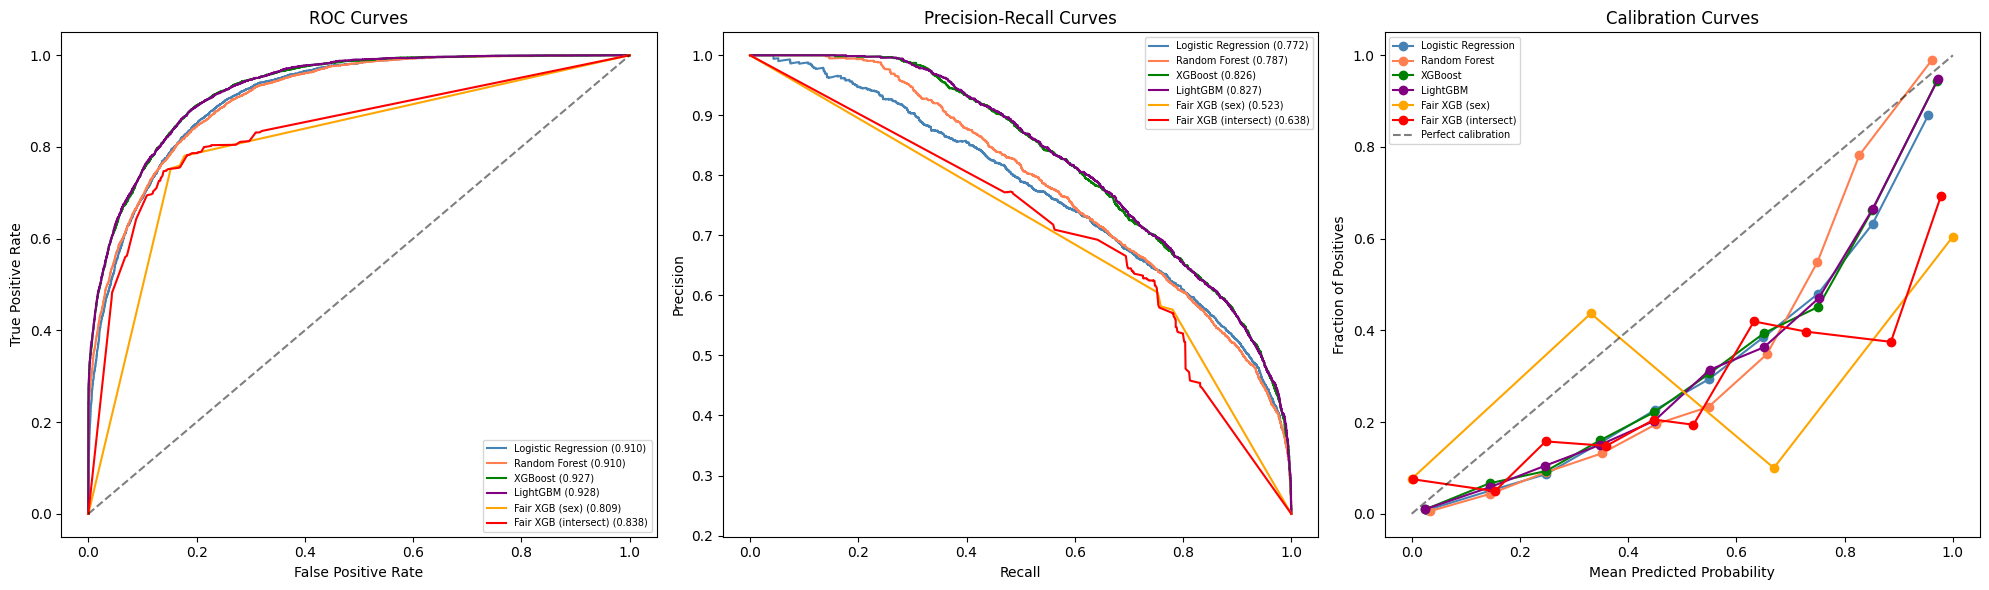

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = {
    "Logistic Regression": (lr_prob, lr_pred),
    "Random Forest": (rf_prob, rf_pred),
    "XGBoost": (xgb_prob, xgb_pred),
    "LightGBM": (lgb_prob, lgb_pred),
    "Fair XGB (sex)": (fair_prob_sex, fair_pred_sex),
    "Fair XGB (intersect)": (fair_prob_intersect, fair_pred_intersect)
}

colors = ["steelblue", "coral", "green", "purple", "orange", "red"]

# ROC curves
for (name, (prob, pred)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({auc:.3f})", color=color)
axes[0].plot([0,1], [0,1], "k--", alpha=0.5)
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=7)

# Precision-Recall curves
for (name, (prob, pred)), color in zip(models.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(recall, precision,
                 label=f"{name} ({ap:.3f})", color=color)
axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=7)

# Calibration curves
for (name, (prob, pred)), color in zip(models.items(), colors):
    fraction_pos, mean_pred = calibration_curve(
        y_test, prob, n_bins=10
    )
    axes[2].plot(mean_pred, fraction_pos, label=name,
                 color=color, marker="o")
axes[2].plot([0,1], [0,1], "k--", alpha=0.5,
             label="Perfect calibration")
axes[2].set_title("Calibration Curves")
axes[2].set_xlabel("Mean Predicted Probability")
axes[2].set_ylabel("Fraction of Positives")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("../reports/figures/full_model_comparison.png", dpi=150)
plt.show()

### Observations — Calibration Curves

**Standard models (LR, RF, XGBoost, LightGBM):**
- All four follow the diagonal closely up to ~0.6 predicted probability
- Slight overconfidence at higher probabilities (curve dips below 
  diagonal above 0.6) — common behavior for tree-based models
- Logistic Regression and LightGBM are the best calibrated overall, 
  staying closest to the diagonal across the full range
- This explains their lower Brier scores

**Fairness-constrained models:**
- Both fair models show erratic, zigzag calibration curves — 
  especially Fair XGB (sex) in orange
- The intersectional model (red) is slightly more stable but 
  still significantly worse than standard models
- This is expected — ExponentiatedGradient optimizes for 
  fairness constraints, not probability calibration. 
  The predicted probabilities are weighted mixtures of 
  multiple sub-models, which distorts calibration.

**Practical implication:**
The poor calibration of fairness-constrained models means their 
probability outputs should not be used directly for downstream 
decisions — only the hard predictions (0/1) are reliable. 
If calibrated probabilities are needed alongside fairness 
constraints, post-hoc calibration via isotonic regression 
would be required as an additional step.

**For deployment:**
XGBoost or LightGBM offer the best balance of discrimination, 
calibration, and performance. The fairness-constrained models 
are valuable for understanding the accuracy-fairness tradeoff 
but require additional calibration work before production use.

## 8. Model Selection Summary

In [41]:
summary = pd.DataFrame({
    "Model": [
        "Logistic Regression", 
        "Random Forest",
        "XGBoost", 
        "LightGBM",
        "Fair XGB (sex)",
        "Fair XGB (intersect)"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, lgb_prob),
        roc_auc_score(y_test, fair_prob_sex),
        roc_auc_score(y_test, fair_prob_intersect)
    ],
    "Avg Precision": [
        average_precision_score(y_test, lr_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob),
        average_precision_score(y_test, lgb_prob),
        average_precision_score(y_test, fair_prob_sex),
        average_precision_score(y_test, fair_prob_intersect)
    ],
    "Brier Score": [
        brier_score_loss(y_test, lr_prob),
        brier_score_loss(y_test, rf_prob),
        brier_score_loss(y_test, xgb_prob),
        brier_score_loss(y_test, lgb_prob),
        brier_score_loss(y_test, fair_prob_sex),
        brier_score_loss(y_test, fair_prob_intersect)
    ],
    "DPD (sex)": [
        demographic_parity_difference(y_test, lr_pred, sensitive_features=X_test["sex"]),
        demographic_parity_difference(y_test, rf_pred, sensitive_features=X_test["sex"]),
        demographic_parity_difference(y_test, xgb_pred, sensitive_features=X_test["sex"]),
        demographic_parity_difference(y_test, lgb_pred, sensitive_features=X_test["sex"]),
        demographic_parity_difference(y_test, fair_pred_sex, sensitive_features=X_test["sex"]),
        demographic_parity_difference(y_test, fair_pred_intersect, sensitive_features=X_test["sex"])
    ]
}).round(4)

summary = summary.set_index("Model")
print(summary.to_string())

                      ROC-AUC  Avg Precision  Brier Score  DPD (sex)
Model                                                               
Logistic Regression    0.9095         0.7722       0.1248     0.3205
Random Forest          0.9098         0.7866       0.1279     0.3550
XGBoost                0.9274         0.8261       0.1089     0.3042
LightGBM               0.9280         0.8274       0.1096     0.3040
Fair XGB (sex)         0.8089         0.5232       0.1770     0.0091
Fair XGB (intersect)   0.8379         0.6384       0.1520     0.0041


## 9. Save the Models

In [1]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

In [ ]:
# Persist fitted pipelines for downstream evaluation
artifacts = {
    "logistic_regression": lr_pipeline,
    "random_forest": rf_pipeline,
    "xgboost": xgb_pipeline,
    "lightgbm": lgb_pipeline,
}

for name, model in artifacts.items():
    out_path = f"../models/{name}.pkl"
    joblib.dump(model, out_path)
    print(f"✓ Saved {name} → {out_path}")

print(f"\nTotal saved: {len(artifacts)}")